# Laboratorium 10 - Warstwy Transformer


Na tym laboratorium zapoznamy się z warstwami Transformer i koncepcją hooks - funkcji, które jesteśmy w stanie "podłączyć" do istniejącego modelu na przejściowych warstwach przetwarzania.

Transformery to warstwy oparte o moduł uwagi. Koncepcja "uwagi" w sieciach głębokich to próba przetwarzania złożonych zależności w **zbiorach** obiektów - niekoniecznie sekwencjach, ale jest to jedno z typowych zastosowań.

Przykładowo, w przetwarzaniu zdania w języku naturalnym mamy problem ze złożonością naturalnej gramatyki, bo zależności niekoniecznie będą działały na zasadzie "każde słowo wpływa tylko na kolejne, następujące po nim słowo" (a wtedy nawięcej sensu miałoby działanie na zasadzie czystej rekurencji).

Zamiast tego, wykorzystanie uwagi oznacza, że przetwarzając słowo, możemy zwrócić **uwagę** na inne słowa **które są dla niego istotne**. Moduł uwagi musi się więc wyuczyć informacji o tym, które słowa są istotne dla siebie nawzajem. W najprostszej implementacji oznacza to porównywanie **każdego słowa z każdym**.

# Warstwa Transformer

Przyjrzyjmy się wewnętrznej strukturze warstwy Transformer:

In [1]:
import torch

transformer = torch.nn.Transformer(d_model=10, nhead=1)

print(transformer)

Transformer(
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=10, out_features=10, bias=True)
        )
        (linear1): Linear(in_features=10, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=10, bias=True)
        (norm1): LayerNorm((10,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((10,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
    (norm): LayerNorm((10,), eps=1e-05, elementwise_affine=True)
  )
  (decoder): TransformerDecoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerDecoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=10, out_featu

/Users/mikolajolesinski/Desktop/glebokie_sieci_neuronowe/listy/.venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(


Ta implementacja podąża za oryginalną strukturą z *Attention is All You Need*, więc rozdziela enkodery i dekodery (ponieważ ta publikacja działała na problemie automatycznego tłumaczenia, gdzie potrzebna jest uwaga ze zdania wyjściowego na inne zdanie wejściowe), ma wiele dodatkowych operacji liniowych, LayerNorm, etc.

Sednem transformerów jest jednak operacja uwagi. Uwaga oparta o moduły self-attention (nazwę transformer w zasadzie mozna zastosować do dowolnych sieci opierających się o ten moduł) daje sieciom głębokim możliwość dopasowania do wielu typów danych w kórych zachodzą relacje między elementami: sekwencji (relacje w czasie), grafów (połączenia), obrazów (relacje pozycyjne w przestrzeni 2d), języka naturalnego (gramatyka) etc. Dzieje się tak, ponieważ bazowy mechanizm to po prostu porównanie każdy-z-każdym, a konkretną topologię problemu dodajemy przez inne mechanizmy, takie jak positional embedding i maskowanie.

# Zasada działania self-attention

Chcemy żeby każdy z elementów sekwencji "zapytał" (**query**) pozostałe elementy o to jak pozostałe elementy są **istotne dla niego**.

Aby to zapytanie miało sens, nasz element potrzebuje też jakiejś reprezentacji mówiącej relewantności dla innnych "pytających" elementów (**key**). W oparciu o to, możemy mnożąc macierze otrzymać macierz `liczba_elementów x liczba_elementów`. Następnie wykonamy na niej operację softmax. W ten sposób każdy element otrzymuj swoje "wagi uwagi" odnośnie wszystkich pozostałych elementów, które dzięki softmaxowi sumują się do jedynki.

Mając takie wagi, możemy zsumować reprezentacje pozostałych elementów wymnożone przez ich wagi. Ponieważ wynik tej operacji ma już iść dalej, a reprezentacje query i key służyły głównie do ustalania istotności elementów względem siebie nawzajem, stworzymy trzecią reprezentację elementów na potrzeby samego sumowania (**value**). W kodzie, dla uproszczenia bez batchowania danych:

In [2]:
sequence = torch.zeros((100,5))

query_projection = torch.nn.Linear(5,3)
key_projection = torch.nn.Linear(5,3)
value_projection = torch.nn.Linear(5,3)


q = query_projection(sequence)
k = key_projection(sequence)
v = value_projection(sequence)

attention = torch.nn.functional.softmax(q @ k.T, dim=-1)

print(attention.shape)

output = attention @ v

print(output.shape)

torch.Size([100, 100])
torch.Size([100, 3])


# Positional Embedding

O ile transformer osiągają imponujące wyniki w zadaniach sekwencyjnych, warto zwrócić uwagę, że zależności sekwencyjne nie są wbudowane w opisaną wyżej architekturę self-attention tak jak zależność, że krok n następuje po n-1 w sieciach rekurencyjnych, czy zależnoci pozycyjne w opercję konwolucji. Możemy wymusić, aby dla zadań predykcyjnych krok czasowy n nie widział króków n+1 i dalszych, ale sąsiedztwo w czasie w dalszym ciągu nie ma odzwierciedlenia w architekturze.

Istnieje bardzo proste rozwiązanie: dodajemy pozycję w sekwencji jako zmienną wejściową. Nie zawsze jest to reprezentacja dosłownie wyrażająca pozycje jako liczbę całkowitą - indeks, ale idea sprowadza się do dodania osadzenia pozycji wejściowej do naszych danych. Osadzenie można uzyskać z apomocą warstwy Mebedding, poznanej w poprzednim zadaniu.

Bardziej zaawansowane mechanizmy wykorzystują dodawanie informacji o pozycji na poziomie mechanizmu uwagi, modifikując wynik operacji mnożenia Q przez K, co pozwala uwzględnić informację o relatywnej pozycji.

## Zadanie 1

Przeprowadź trening sieci złożonej z trzech warstw TransformerEncoderLayer (w torch.nn) na zbiorach z poprzedniego zadania. Użyj jednej z opisanych wyżej wersji positional embedding. Dla klasyfikacji, dodaj osobny token na początku każdego zdania (tak aby sam w sobie nie był słowem).

In [3]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from tqdm.notebook import tqdm
from tensorflow.keras.datasets import imdb
import matplotlib.pyplot as plt

In [27]:
VOCAB_SIZE = 10000
MAX_LEN    = 300
 
(x_train, y_train), (x_test, y_test) = imdb.load_data(
    path='imdb.npz',
    num_words=None,
    skip_top=0,
    maxlen=None,
    seed=113,
    start_char=1,
    oov_char=2,
    index_from=3
)
 
x_train = [[token if token < VOCAB_SIZE else 2 for token in seq[:MAX_LEN]] for seq in x_train]
x_test  = [[token if token < VOCAB_SIZE else 2 for token in seq[:MAX_LEN]] for seq in x_test]
 
print(f"Train: {len(x_train)} przykładów")
print(f"Test:  {len(x_test)} przykładów")
print(f"Przykładowa sekwencja (pierwsze 10 tokenów): {x_train[0][:10]}")

Train: 25000 przykładów
Test:  25000 przykładów
Przykładowa sekwencja (pierwsze 10 tokenów): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65]


In [5]:
BATCH_SIZE = 64
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
 
class IMDBDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
 
    def __len__(self):
        return len(self.X)
 
    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx], dtype=torch.long)
        label = torch.tensor(self.y[idx], dtype=torch.long)
        return x, label
 
 
def collate_transformer(batch):
    sequences, labels = zip(*batch)
 
    CLS_ID = VOCAB_SIZE 
 
    sequences_with_cls = [
        torch.cat([torch.tensor([CLS_ID]), seq])
        for seq in sequences
    ]

    padded = pad_sequence(sequences_with_cls, batch_first=True, padding_value=0)

    mask = (padded == 0)  
 
    return padded, mask, torch.stack(list(labels))
 
 
train_dataset = IMDBDataset(x_train, y_train)
test_dataset  = IMDBDataset(x_test,  y_test)
 
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_transformer)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_transformer)
 

In [6]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model, nhead, num_layers, num_classes,
                 max_len=MAX_LEN + 1, dropout=0.1):
        """
        vocab_size  — rozmiar słownika (+1 na CLS token)
        d_model     — wymiar embeddingu i ukryty rozmiar Transformera
        nhead       — liczba głów uwagi (d_model musi być podzielne przez nhead)
        num_layers  — liczba warstw TransformerEncoderLayer (w zadaniu: 3)
        max_len     — maksymalna długość sekwencji (MAX_LEN + 1 bo CLS)
        """
        super().__init__()
 
        self.token_embedding = nn.Embedding(vocab_size + 1, d_model, padding_idx=0)
 
        self.pos_embedding = nn.Embedding(max_len, d_model)
 
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
 
        self.classifier = nn.Linear(d_model, num_classes)
        self.dropout = nn.Dropout(dropout)
 
    def forward(self, x, key_padding_mask=None):
        """
        x                — (batch, seq_len) tokeny jako int
        key_padding_mask — (batch, seq_len) True gdzie padding
        """
        batch_size, seq_len = x.shape
 
        positions = torch.arange(seq_len, device=x.device)
        positions = positions.unsqueeze(0).expand(batch_size, -1) 
 
        x = self.token_embedding(x) + self.pos_embedding(positions)
        x = self.dropout(x)
 
        x = self.transformer(x, src_key_padding_mask=key_padding_mask) 
 
        cls_output = x[:, 0, :]
 
        return self.classifier(cls_output)
 

In [7]:
def train_transformer(model, train_loader, val_loader, epochs=5, lr=1e-3, device='cpu'):
    model.to(device)
    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
 
    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
 
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [train]", leave=False)
        for tokens, mask, labels in pbar:
            tokens = tokens.to(device)
            mask   = mask.to(device)
            labels = labels.to(device)
 
            optimizer.zero_grad()
            outputs = model(tokens, key_padding_mask=mask)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
 
            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{correct/total:.4f}")
 
        train_loss = total_loss / len(train_loader)
        train_acc  = correct / total
 
        # walidacja
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for tokens, mask, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [val]", leave=False):
                tokens = tokens.to(device)
                mask   = mask.to(device)
                labels = labels.to(device)
 
                outputs = model(tokens, key_padding_mask=mask)
                loss = criterion(outputs, labels)
 
                val_loss    += loss.item()
                preds = outputs.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total   += labels.size(0)
 
        val_loss = val_loss / len(val_loader)
        val_acc  = val_correct / val_total
 
        for k, v in zip(['train_loss','train_acc','val_loss','val_acc'],
                        [train_loss, train_acc, val_loss, val_acc]):
            history[k].append(v)
 
        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
              f"Val loss: {val_loss:.4f}, acc: {val_acc:.4f}")
 
    return history
 
 
def plot_history(history, title='Transformer'):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history['train_loss']) + 1)
    for ax, metric in zip(axes, ['loss', 'acc']):
        ax.plot(epochs, history[f'train_{metric}'], '--', label='train')
        ax.plot(epochs, history[f'val_{metric}'],   '-',  label='val')
        ax.set_title(f'{title} — {metric}')
        ax.legend(); ax.set_xlabel('Epoch')
    plt.tight_layout(); plt.show()

Parametry modelu: 1,913,730


Epoch 1/10 [train]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 1/10 [val]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 1/10 | Train loss: 0.5692, acc: 0.6934 | Val loss: 0.4117, acc: 0.8151


Epoch 2/10 [train]:   0%|          | 0/391 [00:00<?, ?it/s]

...

Epoch 9/10 [val]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 9/10 | Train loss: 0.1653, acc: 0.9378 | Val loss: 0.4305, acc: 0.8632


Epoch 10/10 [train]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 10/10 [val]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 10/10 | Train loss: 0.1508, acc: 0.9440 | Val loss: 0.4246, acc: 0.8632


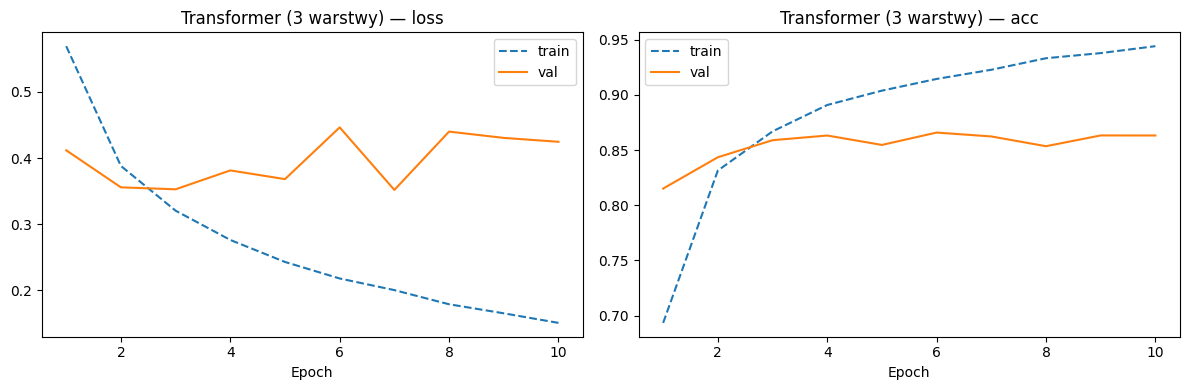

In [11]:
D_MODEL    = 128
NHEAD      = 8
NUM_LAYERS = 3
NUM_CLASSES = 2
EPOCHS     = 10
 
model = TransformerClassifier(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=0.2
)
 
print(f"Parametry modelu: {sum(p.numel() for p in model.parameters()):,}")
 
history = train_transformer(model, train_loader, test_loader, epochs=EPOCHS, lr=1e-3, device=DEVICE)
plot_history(history, title='Transformer (3 warstwy)')

In [ ]:
import os
os.makedirs('models', exist_ok=True)
torch.save(model.state_dict(), 'models/transformer.pt')
print('Model saved → models/transformer.pt')

## Pytorch hooks

Działając z głębokimi sieciami, często korzystać będziemy z gotowych modeli, a jeżeli chcielibyśmy spojrzeć na to, co dzieje się wewnątrz sieci, próba napisania od nowa własnego `forward` które weźmie to pod uwagę nie jest wygodnym rozwiązaniem.

Domyślna klasa reprezentująca warstwę w torchu, czyli `torch.nn.Module`, oferuje nam możliwość wstrzyknięcia własnego kodu zarówno w `forward`, jak i `backward` poprzez rejestrację hooków. Są to funkcje, które automatycznie wywołają się na wejściu, wyjściu lub gradiencie przy przetwarzaniu danych przez tenże moduł.

Dokładniej, dostępne są możliwości:


*   `register_forward_pre_hook` pozwala modyfikować dane przed wywołaniem `forward` modułu, można ustawić flagę `with_kwargs=True` żeby modyfikować też paramtery nazwane (przyda się w zadaniu 2).

      Funkcja podana jako hook powinna mieć format:

      `hook(module, args) -> None or modified_input`

      lub jeśli `use_kwargs=True`

      `hook(module, args, kwargs) -> None or (modified_input, kwargs)`

*   `register_forward_hook` pozwala nam zmodyfikować wyjście po `forward`, analogicznie można ustawić `with_kwargs=True` aby podejrzeć parametry nazwane, ale nie aby je zmodyfikować

*   `register_full_backward_hook` oraz `register_full_backward_pre_hook` w analogiczny sposób dają nam dostęp do gradientu po wyjściach/wejściach do modułu przy wywołaniu `backward`

Po wykorzystaniu hooks, jeżeli chcemy je usunąć przed dalszym korzystaniem z modelu, możemy skorzystać z obiektu `RemovableHandle` zwracanego przez powyższe funkcje.

In [12]:
linear = torch.nn.Linear(5,1)

data_batch = torch.zeros((10,5))
data_batch.requires_grad = True


def input_modifying_hook(module, input):
  print('pre-hook print:\n', input)
  return input[0] + 1

def output_modifying_hook(module, input, output):
  print('forward hook print:\n', input)
  return output + 1


def gradient_printing_hook(module, grad_input, grad_output):
  print('gradient hook print:\n', grad_input)
  return None

def not_firing_hook(module, grad_input, grad_output):
  print('THIS WILL NOT BE PRINTED')
  return None


# na wejściu podajemy zera, więc wyjście powinno być rónwe biasowi
print('layer bias:\n', linear.bias)
print('output without hooks:\n', linear(data_batch))

# po modyfikacji wejścia, wyjście powinno się zmienić
handle = linear.register_forward_pre_hook(input_modifying_hook)
print('output with pre-hook:\n', linear(data_batch))
handle.remove()

# po modyfikacji wyjścia, wyjście powinno się zmienić dokładnie o 1
handle = linear.register_forward_hook(output_modifying_hook)
print('output with forward hook:\n', linear(data_batch))
handle.remove()


handle = linear.register_full_backward_hook(gradient_printing_hook)
out = linear(data_batch).sum()
handle2 = linear.register_full_backward_hook(not_firing_hook)
# obie funkcje są rejestrowane jako backward hook, ale wywoła się tylko gradient_printing_hook
# dlaczego? ponieważ zarejestrowaliśmy not_firing_hook już PO zbudowaniu grafu obliczeniowego
out.backward()

layer bias:
 Parameter containing:
tensor([0.1542], requires_grad=True)
output without hooks:
 tensor([[0.1542],
        [0.1542],
        [0.1542],
        [0.1542],
        [0.1542],
        [0.1542],
        [0.1542],
        [0.1542],
        [0.1542],
        [0.1542]], grad_fn=<AddmmBackward0>)
pre-hook print:
 (tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]], requires_grad=True),)
output with pre-hook:
 tensor([[0.2219],
        [0.2219],
        [0.2219],
        [0.2219],
        [0.2219],
        [0.2219],
        [0.2219],
        [0.2219],
        [0.2219],
        [0.2219]], grad_fn=<AddmmBackward0>)
forward hook print:
 (tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0.

**UWAGA**: wykonywanie hooków może dodać znaczący narzut obliczeniowy, zwłaszcza na karcie graficznej gdzie może wymusić dodatkowe synchronizacje rdzeni. To narzędzie do debuggingu i inspekcji wytrenowanych modeli, nie do wydajnej implementacji nowych funkcjonalności.

# Uwaga a wyjaśnialność

Mechanizm uwagi daje nam jeden z najprostszych mechanizmów interpretowalności modeli - wglądu w oparciu o co nasz black-box podejmuje decyzje. Podglądając wagi uwagi możemy zobaczyć, jak istotne są słowa relatywnie do siebie nawzajem, a patrząc na uwagę w pozycji którą wykorzystujemy do klasyfikacji - na to jak istotne ogólnie są tokeny dla klasyfikatora.

Wyjaśnialność tego typu nazywamy atrybucją i odpowiada ona na pytanie, które wejście jest istotne dla decyzji/wyjścia modelu. Alternatywna intuicja, molzliwa do zastosowania do szerszej puli modeli, to wyjaśnialność oparta o gradient. Założeniem tutaj jest, że jeżeli wyliczymy gradient z wyjścia po wejściu, to będzie on wysoki dla tych wejść które były istotne.

Oba te podejścia można łatwo zaimplementować, korzystając z funkcjonalności forward i backward hooks.

# Zadanie 2

Podepnij do wyuczonego przez siebie modelu hooki, które pozwolą uzyskać inofrmacje o "istotności" wejściowych tokenów dla wyjścia. Istotność n-tego tokenu będzie to odpowiednio: waga uwagi tokenu klasyfikacji na n-tym tokenie lub suma gradientów z wyjścia modelu po wejściu na n-tym tokenie. (Wynikiem w obu przypadkach powinien być tensor gdzie każdemu tokenowi wejściowemu odpowiada jedna wartość "istotności".)  

Zdefiniuj swoje funkcje tak, aby łatwo dało się uzyskać dla wybranego zdania ze zbioru wejściowego istotność na wybranym poziomie sieci (jednej z trzech warstw). Wagi uwagi dostępne będą w module self-attention zadanej warstwy, gradient powinien być wyliczany po wejściu do całej warstwy TransformerEncoderLayer.

Zwizualizuj istotność wejść na podstawie przykładowych zdań ze zbioru IMDB. Spróbuj dobrać zdania, w których będzie widać zarówno podobieństwa, jak i różnice w wyjaśnieniu opartym o gradient vs. o uwagę.

POSITIVE: ['<START>', "i'm", 'absolutely', 'disgusted', 'this', 'movie', "isn't", 'being', 'sold', 'all', 'who', 'love', 'this', 'movie', 'should']
NEGATIVE: ['<START>', 'please', 'give', 'this', 'one', 'a', 'miss', 'br', 'br', '<OOV>', '<OOV>', 'and', 'the', 'rest', 'of']


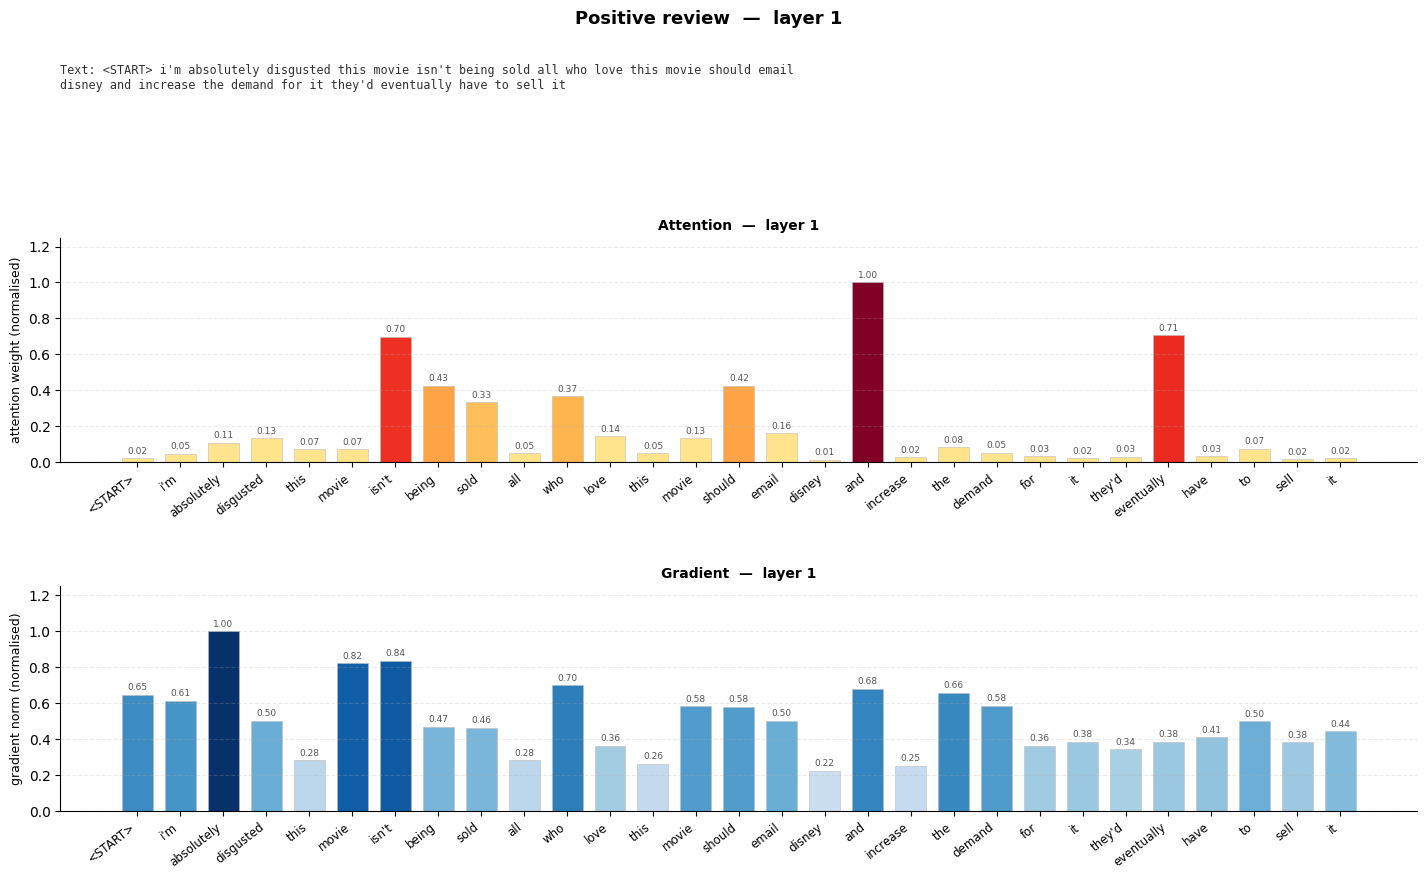

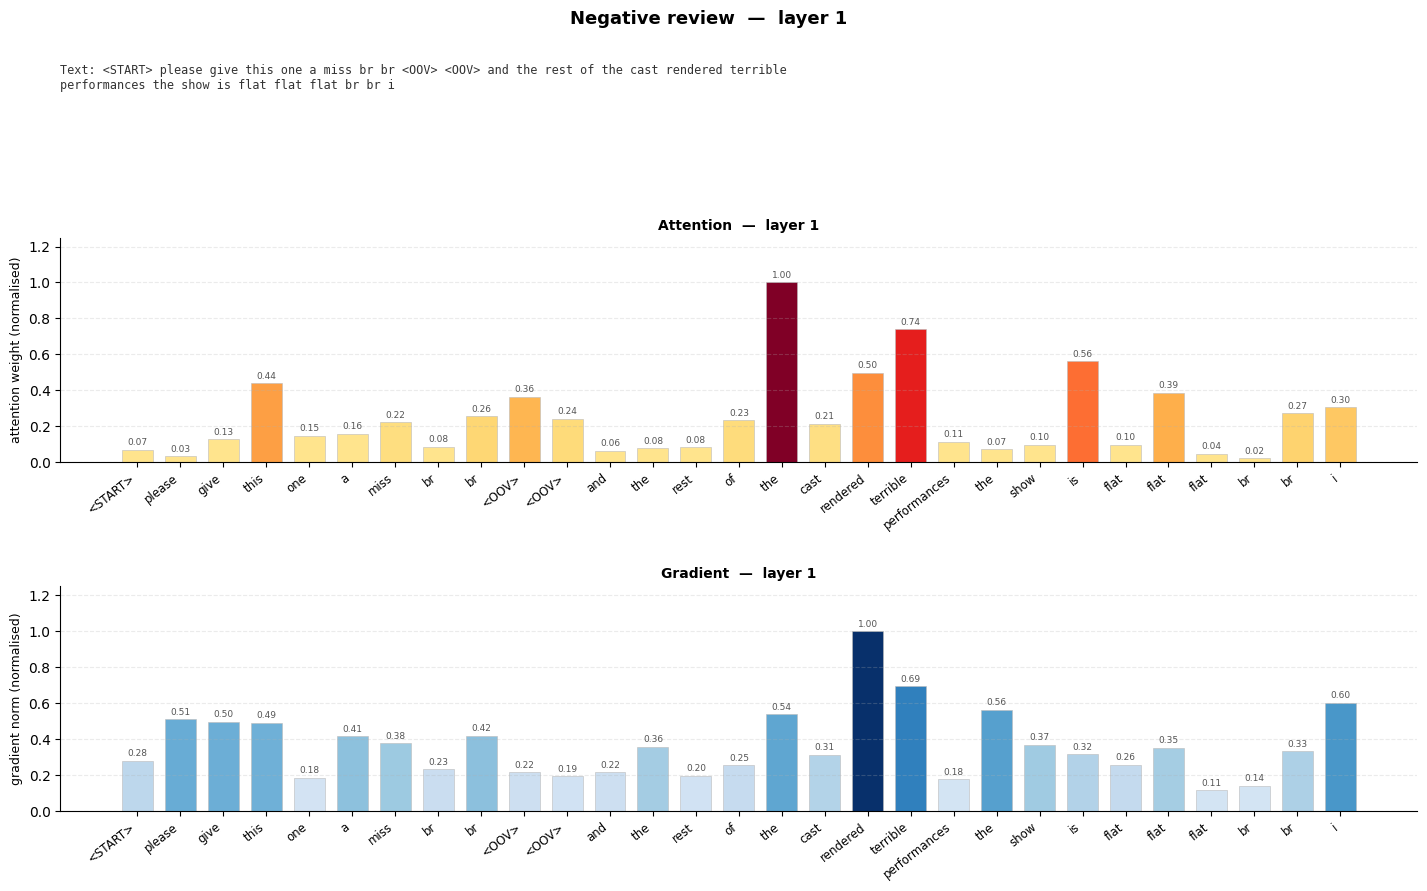

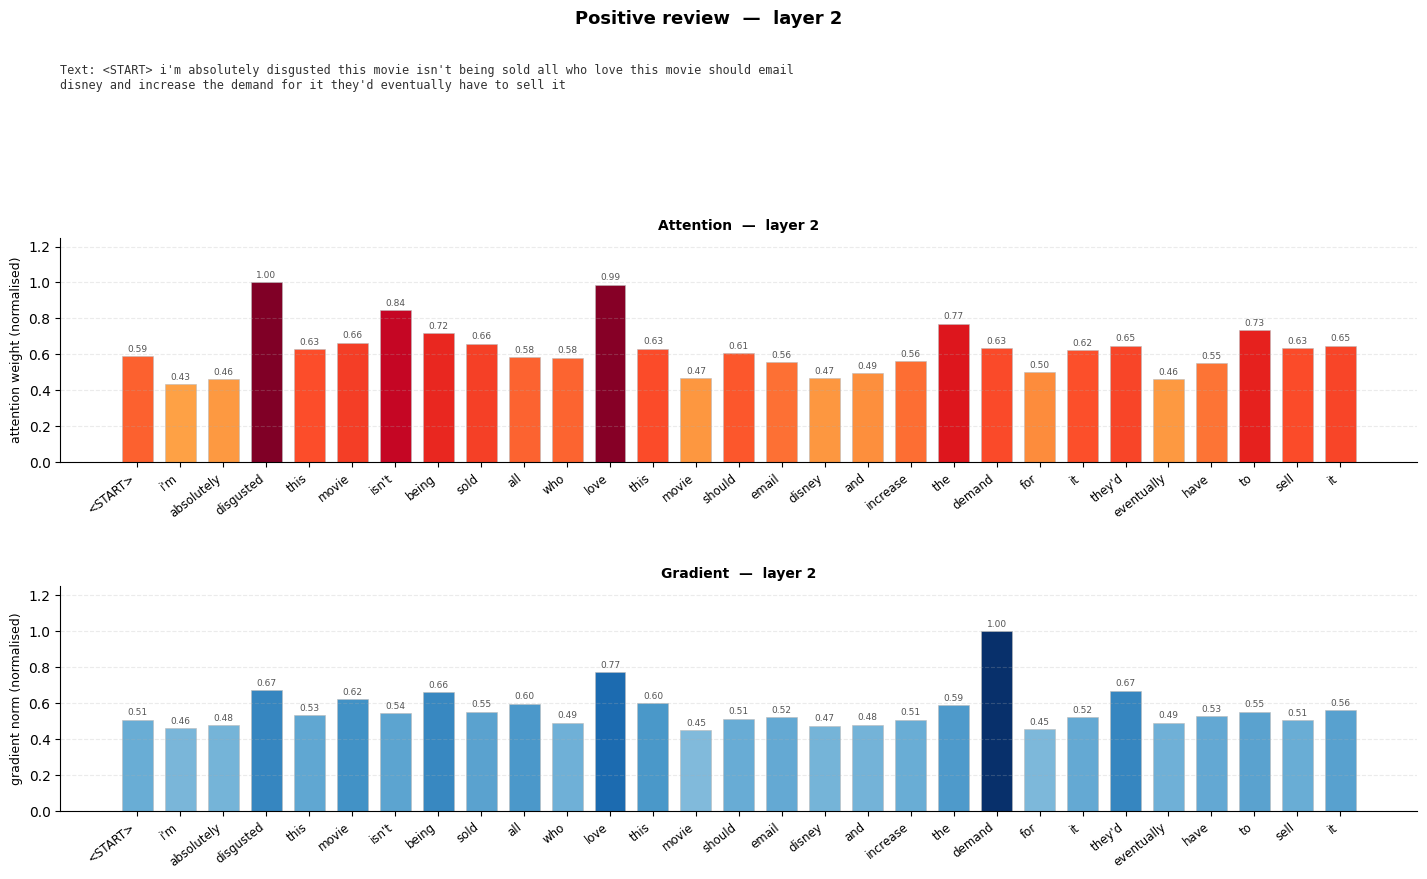

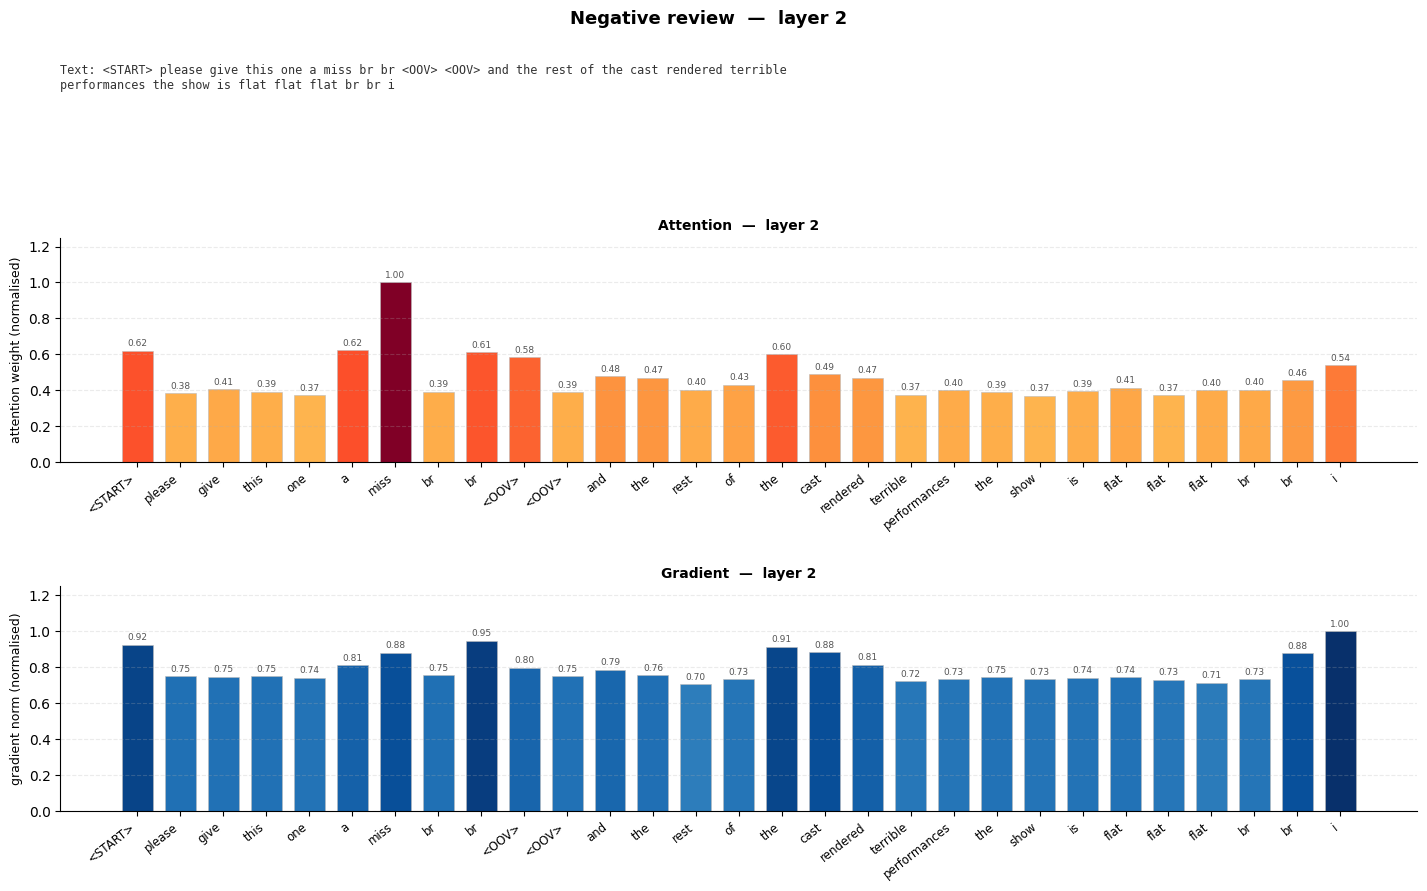

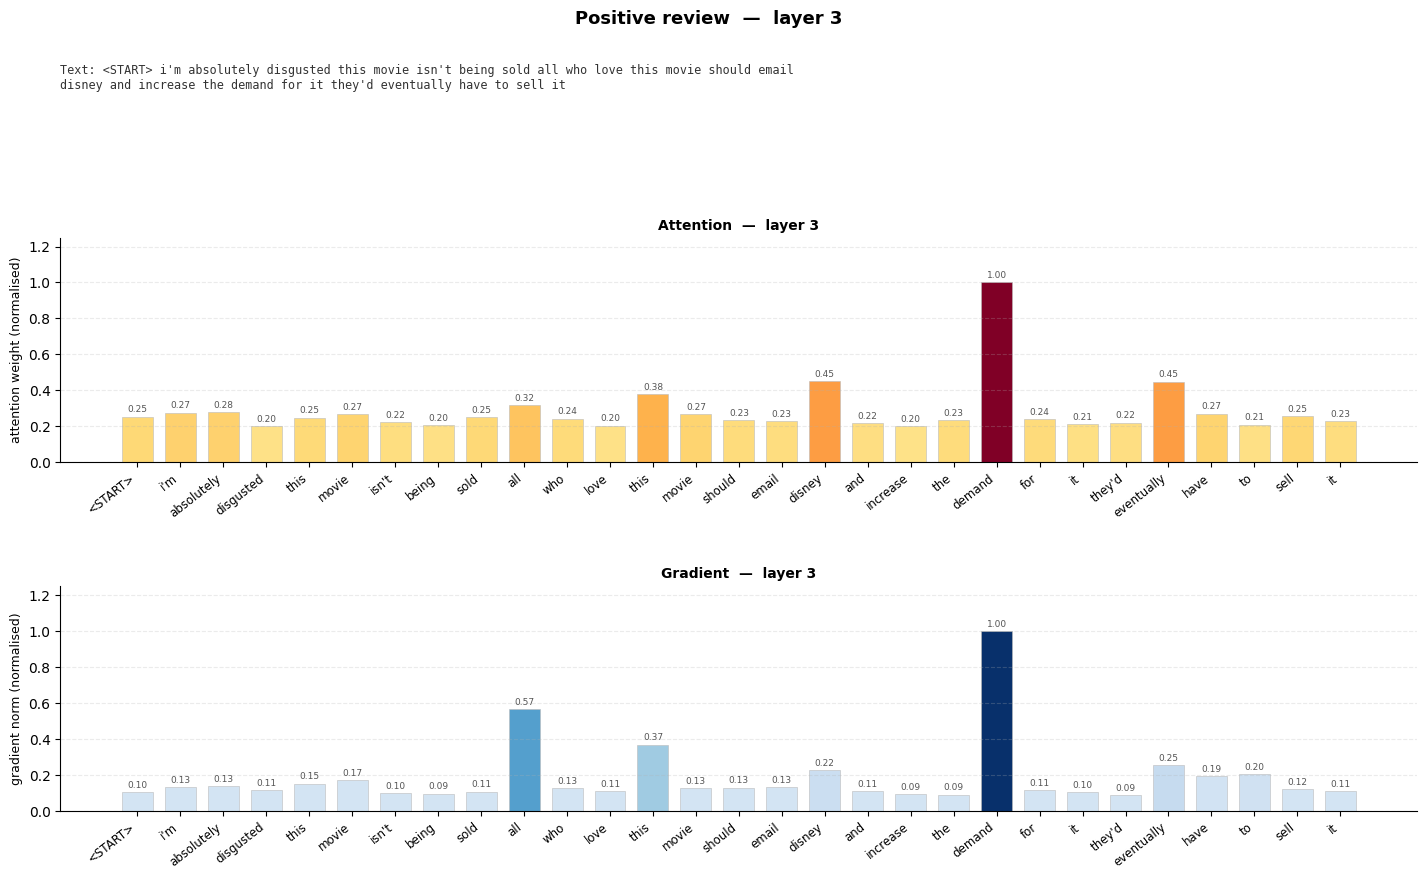

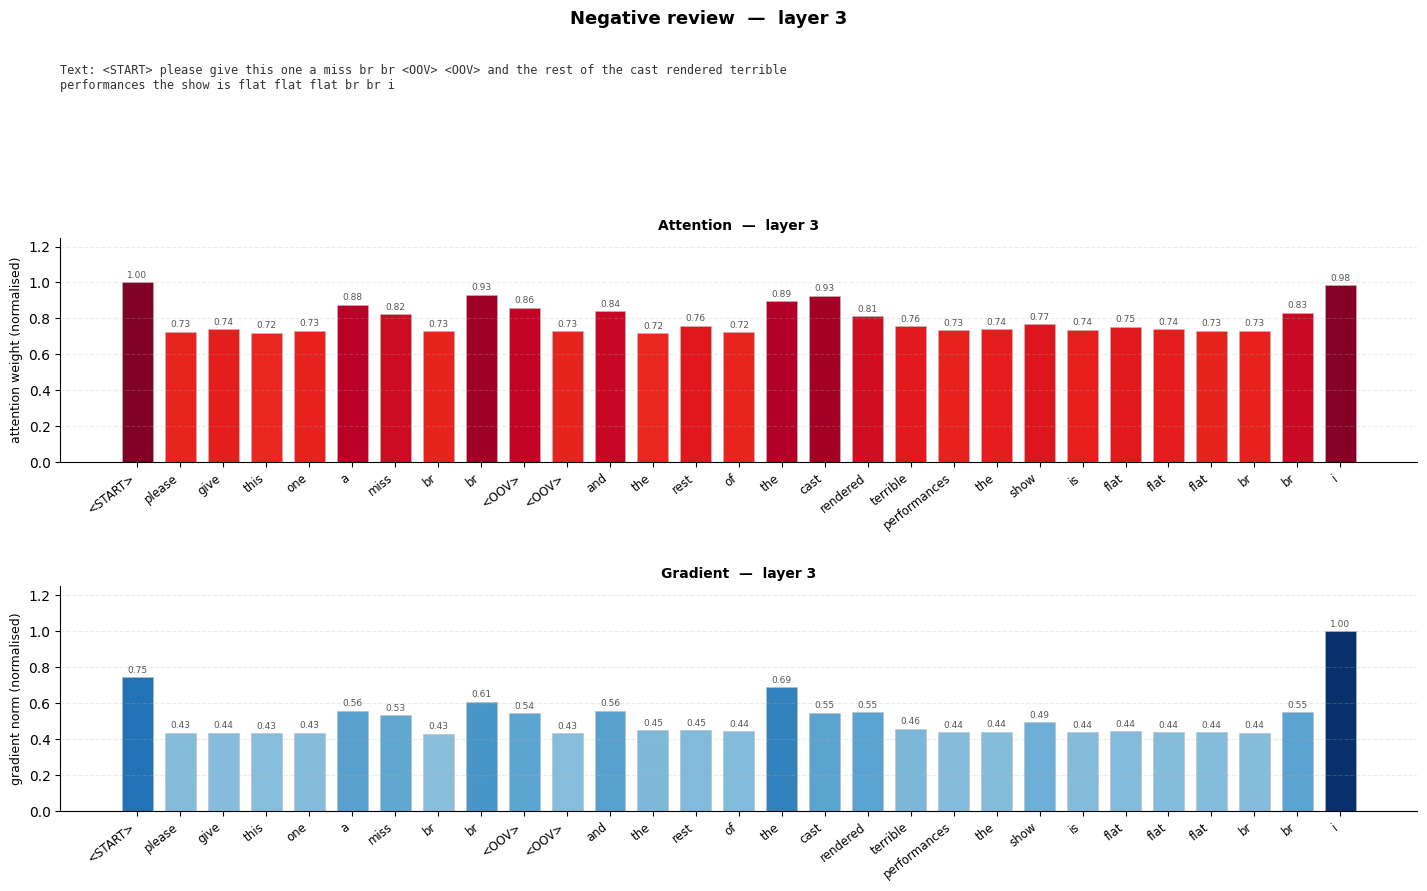

In [31]:
# ── CELL 1: word index ────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')
from tensorflow.keras.datasets import imdb as keras_imdb

word_idx    = keras_imdb.get_word_index()
idx_to_word = {v + 3: k for k, v in word_idx.items()}
idx_to_word[0] = '<PAD>'
idx_to_word[1] = '<START>'
idx_to_word[2] = '<OOV>'

# model = TransformerClassifier(
#     vocab_size=VOCAB_SIZE,
#     d_model=D_MODEL,
#     nhead=NHEAD,
#     num_layers=NUM_LAYERS,
#     num_classes=NUM_CLASSES,
#     dropout=0.1
# )

# model.load_state_dict(torch.load('models/transformer.pt', map_location=DEVICE))
# model.to(DEVICE)
# model.eval()
# print('Model loaded.')


# ── CELL 2: pick example sentences ────────────────────────────────────────────

pos_seq = x_test[5]
neg_seq = x_test[0]

print('POSITIVE:', [idx_to_word.get(i, '?') for i in pos_seq[:15]])
print('NEGATIVE:', [idx_to_word.get(i, '?') for i in neg_seq[:15]])


# ── CELL 3: analyze sentence ──────────────────────────────────────────────────

import torch

def analyze_sentence(model, sequence, layer_idx=0, max_words=30, device='cpu'):
    model.eval()
    seq_cut = sequence[:max_words]
    tokens  = [idx_to_word.get(i, '?') for i in seq_cut]
    x       = torch.tensor([seq_cut], dtype=torch.long, device=device)

    captured = {'attn': None, 'grad': None}

    def attn_hook(module, input, output):
        captured['attn'] = output[1].detach().cpu()

    def grad_hook(module, grad_input, grad_output):
        if grad_input[0] is not None:
            captured['grad'] = grad_input[0].detach().cpu()

    target_layer = model.transformer.layers[layer_idx]

    original_forward = target_layer.self_attn.forward
    def patched_forward(*args, **kwargs):
        kwargs['need_weights']         = True
        kwargs['average_attn_weights'] = True
        return original_forward(*args, **kwargs)
    target_layer.self_attn.forward = patched_forward

    h1 = target_layer.self_attn.register_forward_hook(attn_hook)
    h2 = target_layer.register_full_backward_hook(grad_hook)

    out = model(x)
    out.sum().backward()

    target_layer.self_attn.forward = original_forward
    h1.remove()
    h2.remove()

    attn_scores = captured['attn'][0, 0, 1:len(seq_cut) + 1]

    grad        = captured['grad'][0, 1:len(seq_cut) + 1]
    grad_scores = grad.norm(dim=-1)
    grad_scores = grad_scores / (grad_scores.max() + 1e-8)

    return tokens, attn_scores, grad_scores


# ── CELL 4: plot ───────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import textwrap

def plot_importance(tokens, attn_scores, grad_scores, title='', layer_idx=0):
    n       = len(tokens)
    x       = np.arange(n)
    attn_np = attn_scores.detach().numpy()
    attn_np = attn_np / (attn_np.max() + 1e-8)
    grad_np = grad_scores.detach().numpy()
    n       = min(len(tokens), len(attn_np), len(grad_np))
    tokens  = tokens[:n]
    attn_np = attn_np[:n]
    grad_np = grad_np[:n]
    x       = np.arange(n)

    # ── figure layout ─────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(max(13, n * 0.52), 9))
    gs  = gridspec.GridSpec(
        3, 1,
        height_ratios=[0.55, 2.5, 2.5],
        hspace=0.75,
        top=0.93, bottom=0.1, left=0.07, right=0.97
    )

    # ── title + sentence text ─────────────────────────────────────────────────
    ax_info = fig.add_subplot(gs[0])
    ax_info.axis('off')

    sentence = ' '.join(tokens)
    wrapped  = '\n'.join(textwrap.wrap(sentence, width=100))

    fig.suptitle(title, fontsize=13, fontweight='bold', y=0.99)
    ax_info.text(0, 1.0, f'Text: {wrapped}',
                 transform=ax_info.transAxes,
                 fontsize=8.5, color='#333333', va='top', family='monospace')

    # ── shared bar style ──────────────────────────────────────────────────────
    bar_kwargs = dict(edgecolor='#bbbbbb', linewidth=0.4, width=0.72)

    def add_value_labels(ax, bars, values):
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    val + 0.015, f'{val:.2f}',
                    ha='center', va='bottom', fontsize=6.5, color='#555555')

    # ── attention plot ────────────────────────────────────────────────────────
    ax1   = fig.add_subplot(gs[1])
    cmap1 = plt.get_cmap('YlOrRd')
    bars1 = ax1.bar(x, attn_np,
                    color=[cmap1(max(v, 0.18)) for v in attn_np],
                    **bar_kwargs)
    ax1.set_title(f'Attention  —  layer {layer_idx + 1}',
                  fontsize=10, fontweight='bold', pad=6)
    ax1.set_ylabel('attention weight (normalised)', fontsize=9)
    ax1.set_xticks(x)
    ax1.set_xticklabels(tokens, rotation=38, ha='right', fontsize=8.5)
    ax1.set_ylim(0, 1.25)
    ax1.spines[['top', 'right']].set_visible(False)
    ax1.grid(axis='y', alpha=0.25, linestyle='--')
    add_value_labels(ax1, bars1, attn_np)

    # ── gradient plot ─────────────────────────────────────────────────────────
    ax2   = fig.add_subplot(gs[2])
    cmap2 = plt.get_cmap('Blues')
    bars2 = ax2.bar(x, grad_np,
                    color=[cmap2(max(v, 0.18)) for v in grad_np],
                    **bar_kwargs)
    ax2.set_title(f'Gradient  —  layer {layer_idx + 1}',
                  fontsize=10, fontweight='bold', pad=6)
    ax2.set_ylabel('gradient norm (normalised)', fontsize=9)
    ax2.set_xticks(x)
    ax2.set_xticklabels(tokens, rotation=38, ha='right', fontsize=8.5)
    ax2.set_ylim(0, 1.25)
    ax2.spines[['top', 'right']].set_visible(False)
    ax2.grid(axis='y', alpha=0.25, linestyle='--')
    add_value_labels(ax2, bars2, grad_np)

    plt.show()


# ── CELL 5: run ────────────────────────────────────────────────────────────────

for layer_idx in [0, 1, 2]:
    tokens, attn, grad = analyze_sentence(
        model, pos_seq, layer_idx=layer_idx, max_words=30, device=DEVICE)
    plot_importance(tokens, attn, grad,
                    title=f'Positive review  —  layer {layer_idx + 1}',
                    layer_idx=layer_idx)

    tokens, attn, grad = analyze_sentence(
        model, neg_seq, layer_idx=layer_idx, max_words=30, device=DEVICE)
    plot_importance(tokens, attn, grad,
                    title=f'Negative review  —  layer {layer_idx + 1}',
                    layer_idx=layer_idx)